# RNN MFCC-10
Trains multilabel and binary UUV BiLSTMs for normal, M-filtered, and W-filtered MFCC-10 data.

In [1]:
import sys
from pathlib import Path

UTILS_GITHUB_RAW_BASE_URL = "https://raw.githubusercontent.com/Nabuhodonozzor/uuv-detection/main/utils"
COMMON_UTILS_FILE = "common_utils.py"
MODEL_UTILS_FILE = "rnn_utils.py"
MODEL_DIR = "RNN"
common_dirs = [Path.cwd() / "utils", Path.cwd().parent / "utils", Path("/content/utils"), Path("/content/drive/MyDrive/STUDA/src/utils")]
model_dirs = [Path.cwd(), Path.cwd() / MODEL_DIR, Path.cwd().parent / MODEL_DIR, Path("/content") / MODEL_DIR, Path("/content/drive/MyDrive/STUDA/src") / MODEL_DIR]
common_dir = next((directory for directory in common_dirs if (directory / COMMON_UTILS_FILE).exists()), None)
model_dir = next((directory for directory in model_dirs if (directory / MODEL_UTILS_FILE).exists()), None)

if (common_dir is None or model_dir is None) and UTILS_GITHUB_RAW_BASE_URL:
    import urllib.request
    common_dir, model_dir = Path("/content/utils"), Path("/content") / MODEL_DIR
    common_dir.mkdir(parents=True, exist_ok=True)
    model_dir.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(f"{UTILS_GITHUB_RAW_BASE_URL}/common_utils.py", common_dir / COMMON_UTILS_FILE)
    urllib.request.urlretrieve(f"https://raw.githubusercontent.com/Nabuhodonozzor/uuv-detection/main/{MODEL_DIR}/{MODEL_UTILS_FILE}", model_dir / MODEL_UTILS_FILE)

if common_dir is None or model_dir is None:
    raise FileNotFoundError("Required common and model utility files were not found.")

sys.path.insert(0, str(common_dir))
sys.path.insert(0, str(model_dir))


Using pipeline module: /content/spectrogram_pipeline.py


In [2]:
import pandas as pd
import tensorflow as tf
from IPython.display import display
from google.colab import files

from common_utils import configure_kaggle_access, evaluate_models_for_variants, extract_zip, plot_training_histories, prepare_mfcc_dataset_variants, save_keras_artifacts, train_keras_models_for_variants, zip_artifacts
from rnn_utils import build_rnn_models_for_variants, get_rnn_callbacks

gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    raise RuntimeError("No GPU is attached. Select a GPU runtime and restart the session.")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f"Using GPU: {gpus[0].name}")


Using GPU: /physical_device:GPU:0


In [3]:
import os
import tensorflow as tf

print("COLAB_TPU_ADDR:", os.environ.get("COLAB_TPU_ADDR"))
print("TPU devices:", tf.config.list_logical_devices("TPU"))

COLAB_TPU_ADDR: None
TPU devices: []


In [4]:
DATASET_KEY = "mfcc10"
DATASET_LABEL = "MFCC-10"
DATASET_SLUG = "pawedyrda/mfcc10"
ARCHIVE_PATH = Path("/content/mfcc10.zip")
EPOCHS = 50
BATCH_SIZE = 64


In [5]:
configure_kaggle_access()


In [6]:
!kaggle datasets download -d {DATASET_SLUG} -p /content --force
DATA_PATH = extract_zip(ARCHIVE_PATH, "/content")
print(f"Dataset extracted to: {DATA_PATH}")


Dataset URL: https://www.kaggle.com/datasets/pawedyrda/mfcc10
License(s): unknown
100% 218M/218M [00:11<00:00, 19.1MB/s] 

Dataset extracted to: /content/mfcc10


In [7]:
variants = prepare_mfcc_dataset_variants(DATA_PATH)
print("Normal train shape:", variants.normal.train_data.shape)
print("M train shape:", variants.m.train_data.shape)
print("W train shape:", variants.w.train_data.shape)


Scanning feature data in: /content/mfcc10
Found .npz files: 9527, skipped: 0
Loaded samples: 9527
X shape: (9527, 618, 10)
y shape: (9527, 17)
Scanning feature data in: /content/mfcc10 (UUV filter: M)
Found .npz files: 9527, skipped: 523
Loaded samples: 9004
X shape: (9004, 618, 10)
y shape: (9004, 17)
Scanning feature data in: /content/mfcc10 (UUV filter: W)
Found .npz files: 9527, skipped: 379
Loaded samples: 9148
X shape: (9148, 618, 10)
y shape: (9148, 17)
Normal train shape: (6096, 618, 10)
M train shape: (5762, 618, 10)
W train shape: (5854, 618, 10)


In [8]:
multilabel_models = build_rnn_models_for_variants(variants, model_type="multilabel")

multilabel_histories = train_keras_models_for_variants(
    multilabel_models, variants, model_type="multilabel", epochs=EPOCHS,
    batch_size=BATCH_SIZE, callback_factory=get_rnn_callbacks,
)


Training multilabel model for variant: normal
Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 130ms/step - binary_accuracy: 0.8949 - loss: 0.2781 - pr_auc: 0.0925 - precision: 0.3184 - recall: 0.1890 - roc_auc: 0.5149 - val_binary_accuracy: 0.9163 - val_loss: 0.2173 - val_pr_auc: 0.1572 - val_precision: 0.7234 - val_recall: 0.0308 - val_roc_auc: 0.5552 - learning_rate: 0.0010
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - binary_accuracy: 0.9139 - loss: 0.2234 - pr_auc: 0.1345 - precision: 0.5047 - recall: 0.2156 - roc_auc: 0.5701 - val_binary_accuracy: 0.9206 - val_loss: 0.2027 - val_pr_auc: 0.2089 - val_precision: 0.5560 - val_recall: 0.3415 - val_roc_auc: 0.6844 - learning_rate: 0.0010
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - binary_accuracy: 0.9188 - loss: 0.2069 - pr_auc: 0.1754 - precision: 0.5594 - recall: 0.2882 - roc_auc: 0.6636 - val_binary_accuracy: 0.9236 - val_loss: 0.1950 - val_pr_auc: 0.2682 - val_precision: 0.5796 - val_recall: 0.3804 - val_roc_auc: 0.78

In [9]:
binary_models = build_rnn_models_for_variants(variants, model_type="binary")

binary_histories = train_keras_models_for_variants(
    binary_models, variants, model_type="binary", epochs=EPOCHS,
    batch_size=BATCH_SIZE, callback_factory=get_rnn_callbacks,
)


Training binary model for variant: normal
Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step - binary_accuracy: 0.9109 - loss: 0.2723 - pr_auc: 0.3369 - precision: 0.6143 - recall: 0.1496 - roc_auc: 0.7432 - val_binary_accuracy: 0.9311 - val_loss: 0.2056 - val_pr_auc: 0.5663 - val_precision: 0.7164 - val_recall: 0.3582 - val_roc_auc: 0.8622 - learning_rate: 0.0010
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - binary_accuracy: 0.9254 - loss: 0.2264 - pr_auc: 0.5148 - precision: 0.7158 - recall: 0.3461 - roc_auc: 0.8362 - val_binary_accuracy: 0.9410 - val_loss: 0.1703 - val_pr_auc: 0.6918 - val_precision: 0.8793 - val_recall: 0.3806 - val_roc_auc: 0.9231 - learning_rate: 0.0010
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - binary_accuracy: 0.9411 - loss: 0.1873 - pr_auc: 0.6512 - precision: 0.8673 - recall: 0.4435 - roc_auc: 0.8920 - val_binary_accuracy: 0.9351 - val_loss: 0.1725 - val_pr_auc: 0.6422 - val_precision: 0.7536 - val_recall: 0.3881 - val_roc_auc: 0.9140 -

In [10]:
multilabel_results = evaluate_models_for_variants(multilabel_models, variants, "multilabel", DATASET_LABEL)
binary_results = evaluate_models_for_variants(binary_models, variants, "binary", DATASET_LABEL)
comparison_results = pd.concat([
    multilabel_results.assign(task="multilabel"),
    binary_results.assign(task="binary"),
], ignore_index=True)
display(comparison_results[["task", "Model", "precision", "recall", "f1-score", "support"]])



--- Evaluation for: Multilabel normal MFCC-10 ---

                   precision    recall  f1-score   support

ArtificialSignals       0.89      0.78      0.83       203
 BigPassengerShip       0.64      0.56      0.60        25
            Cargo       0.67      0.22      0.33        36
         FishBoat       0.82      0.71      0.76        51
        GreenCity       0.66      0.45      0.53        98
           KaiYan       0.50      0.04      0.07        25
          KaiYuan       0.64      0.40      0.49       252
        MotorBoat       1.00      0.62      0.77        24
              No7       0.79      0.36      0.50       124
       PoliceBoat       0.58      0.33      0.42        21
          QianDao       0.81      0.81      0.81       657
        SpeedBoat       0.76      0.76      0.76       851
          TheEarl       0.80      0.71      0.75        99
        TheKnight       0.62      0.47      0.54        55
              UUV       0.89      0.77      0.82       193
   

,task,Model,precision,recall,f1-score,support
0,multilabel,Multilabel normal MFCC-10,0.891566,0.766839,0.824513,193.0
1,multilabel,Multilabel M MFCC-10,0.836066,0.600000,0.698630,85.0
2,multilabel,Multilabel W MFCC-10,0.989899,0.933333,0.960784,105.0
3,binary,Binary normal MFCC-10,0.914894,0.668394,0.772455,193.0
4,binary,Binary M MFCC-10,0.868421,0.388235,0.536585,85.0
5,binary,Binary W MFCC-10,0.978723,0.876190,0.924623,105.0


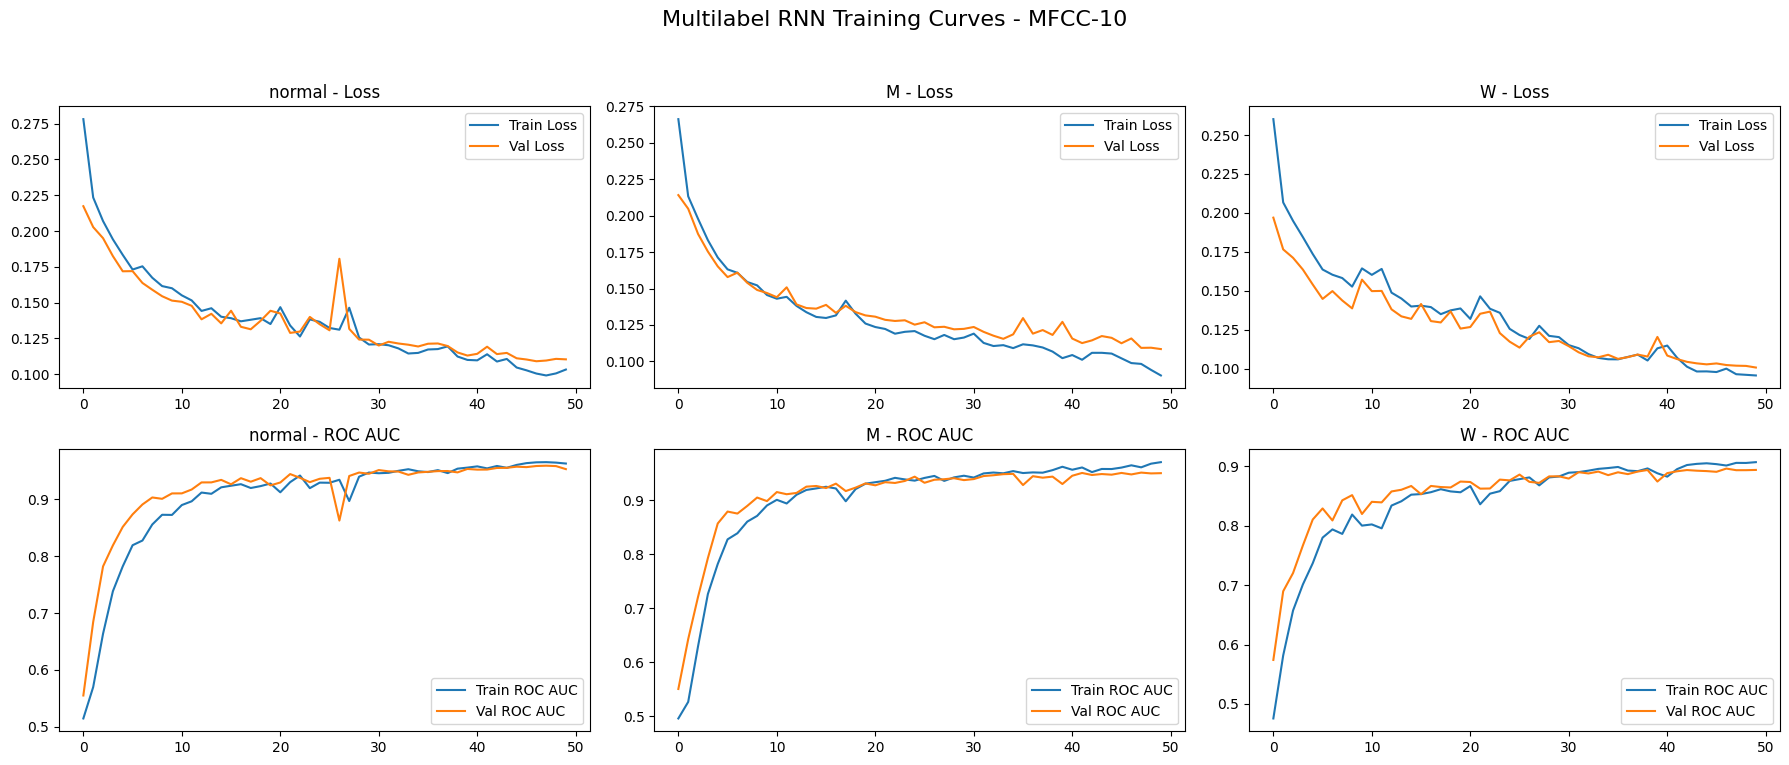

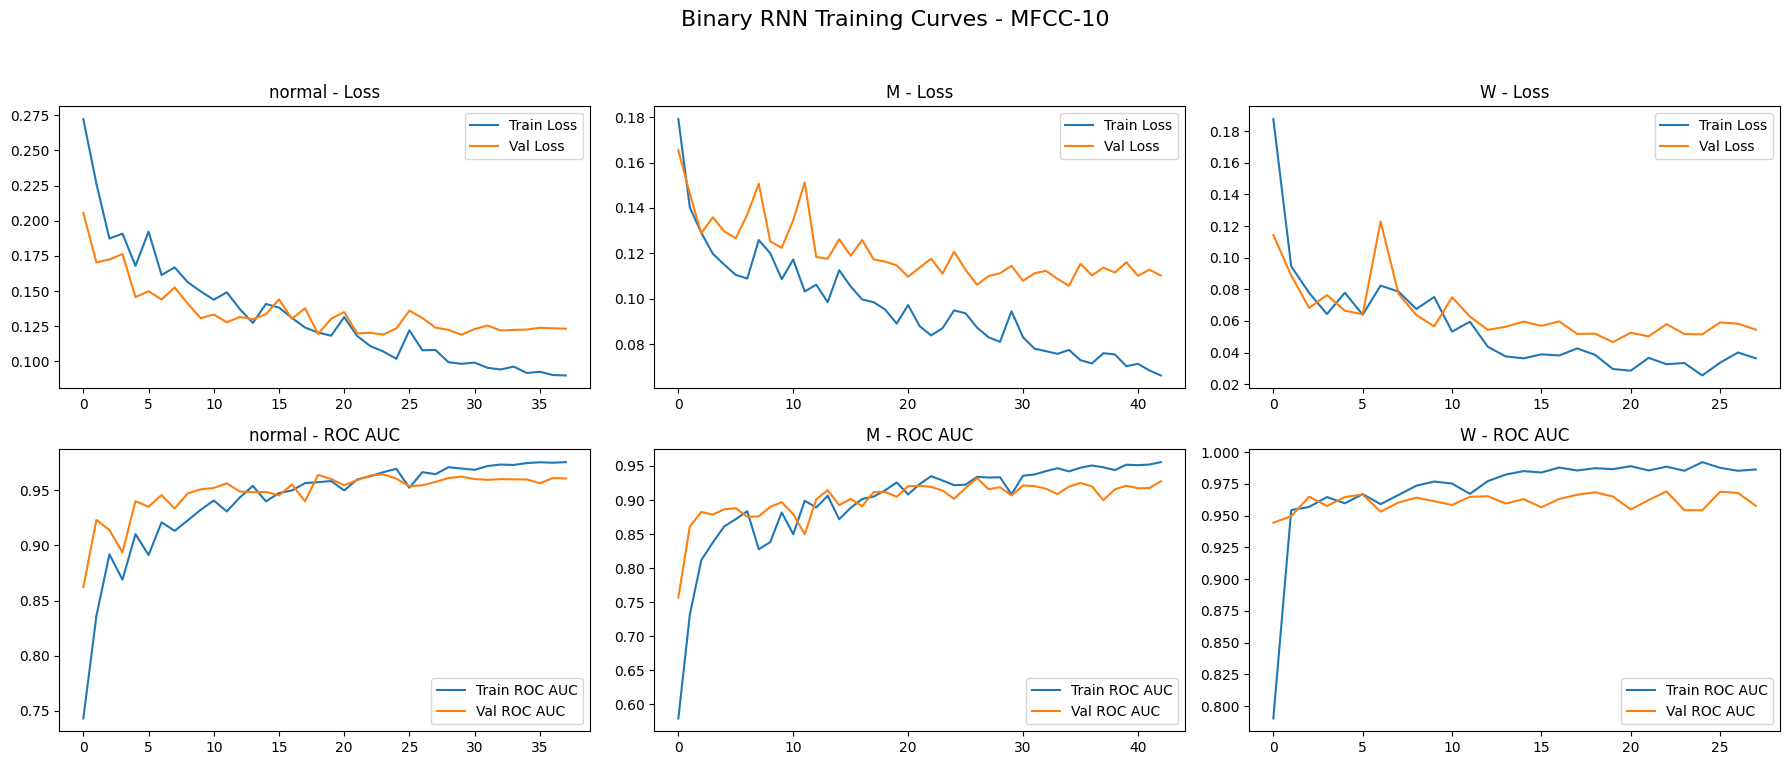

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
plot_training_histories(multilabel_histories, f"Multilabel RNN Training Curves - {DATASET_LABEL}")
plot_training_histories(binary_histories, f"Binary RNN Training Curves - {DATASET_LABEL}")

save_dir = save_keras_artifacts(
    f"/content/saved_artifacts/rnn_{DATASET_KEY}", DATASET_KEY, multilabel_models, binary_models,
    multilabel_histories, binary_histories, multilabel_results, binary_results,
)
comparison_results.to_csv(save_dir / f"rnn_comparison_{DATASET_KEY}.csv", index=False)
archive_path = zip_artifacts(save_dir, f"/content/rnn_models_and_results_{DATASET_KEY}.zip")
files.download(str(archive_path))
